In [49]:
from lcr.config import PROCESSED_DATA_DIR
import pandas as pd
contextual_queries = pd.read_json(PROCESSED_DATA_DIR / "danish_final_cluster_r10/merged/contextual_queries.jsonl", lines=True)
chunks = pd.read_json(PROCESSED_DATA_DIR / "danish_final_cluster_r10/merged/chunks.jsonl", lines=True)
chunks['doc_name'] = chunks['chunk_id'].apply(lambda x: x.split('_')[0])

queries = contextual_queries.merge(chunks, on='chunk_id')
chunks.set_index('chunk_id', inplace=True)

def id_to_idx(chunk_id):
    return chunks.loc[chunk_id, 'chunk_idx']

queries['utilized_idx'] = queries['utilized_context_chunk_ids'].apply(lambda ccids: [id_to_idx(ccid) for ccid in ccids])

def get_max_diff(utilized_idxs: list[int], chunk_idx: int) -> int:
    return max(abs(utilized_idx - chunk_idx) for utilized_idx in utilized_idxs)
# max utilized idx
queries['max_utilized_diff_idx'] = queries[['utilized_idx', 'chunk_idx']].apply(lambda row: get_max_diff(row['utilized_idx'], row['chunk_idx']), axis=1)

print(f"Got max utilized diff idx for {len(queries)} queries")

Got max utilized diff idx for 158 queries


### Chunk distances

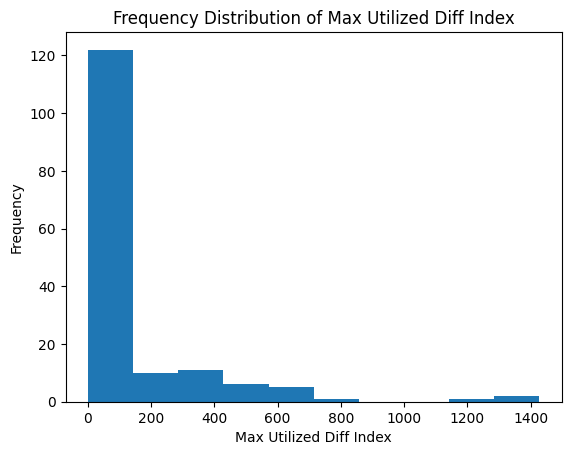

In [52]:
queries['max_utilized_diff_idx']
# do the frequency distribution of max_utilized_diff_idx
import matplotlib.pyplot as plt
plt.hist(queries['max_utilized_diff_idx'])
plt.xlabel('Max Utilized Diff Index')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Max Utilized Diff Index')
plt.show()

### Token distances

In [14]:
chunks.iloc[3000:4000]

,chunk,chunk_idx,implicit_context_chunks,explicit_context_chunks,doc_name,num_tokens,cumulative_tokens
chunk_id,,,,,,,
barnetslov_§146_stk3,Stk. 3. Indbringelse af en afgørelse for Ankes...,542,"[barnetslov_§146_stk1, barnetslov_§146_stk2, b...",[],barnetslov,95,53789
barnetslov_§146_stk4,Stk. 4. Ved behandlingen i Ankestyrelsen finde...,543,"[barnetslov_§146_stk1, barnetslov_§146_stk2, b...","[barnetslov_§140_stk1, barnetslov_§140_stk2, b...",barnetslov,153,53942
barnetslov_§146_stk5,Stk. 5. I forbindelse med behandlingen af en s...,544,"[barnetslov_§146_stk1, barnetslov_§146_stk2, b...",[],barnetslov,75,54017
barnetslov_nonpar_545,Domstolsprøvelse,545,[],[],barnetslov,7,54024
barnetslov_§147_stk1,§ 147. Ankestyrelsens afgørelser efter § 146 o...,546,[barnetslov_§147_stk2],"[barnetslov_§146_stk1, barnetslov_§146_stk2, b...",barnetslov,82,54106
...,...,...,...,...,...,...,...
selskabsloven_§57a_stk5,"Stk. 5. Oplysninger, som er registreret i medf...",237,"[selskabsloven_§57a_stk1, selskabsloven_§57a_s...","[selskabsloven_§57a_stk1, selskabsloven_§57a_s...",selskabsloven,191,20630
selskabsloven_§57a_stk6,Stk. 6. Erhvervsstyrelsen fastsætter nærmere r...,238,"[selskabsloven_§57a_stk1, selskabsloven_§57a_s...",[],selskabsloven,76,20706
selskabsloven_nonpar_239,Ejerregister,239,[],[],selskabsloven,3,20709


In [22]:
chunks.loc['barnetslov_§148_stk4', 'cumulative_tokens']

np.int64(54424)

In [23]:
chunks

,chunk,chunk_idx,implicit_context_chunks,explicit_context_chunks,doc_name,num_tokens,cumulative_tokens
chunk_id,,,,,,,
aaregnskabsloven_nonpar_0,Bekendtgørelse af årsregnskabsloven 1),0,[],[],aaregnskabsloven,19,19
aaregnskabsloven_nonpar_1,"Herved bekendtgøres årsregnskabsloven, jf. lov...",1,[],[],aaregnskabsloven,141,160
aaregnskabsloven_nonpar_2,"Den ændring, der følger af § 1, nr. 23, i lov ...",2,[],[],aaregnskabsloven,194,354
aaregnskabsloven_nonpar_3,Afsnit I,3,[],[],aaregnskabsloven,4,358
aaregnskabsloven_nonpar_4,"Lovens anvendelsesområde, grundlæggende krav m.v.",4,[],[],aaregnskabsloven,20,378
...,...,...,...,...,...,...,...
straffeloven_nonpar_1008,"30) Lovændringen vedrører § 244, stk. 2, og § ...",1008,[],[],straffeloven,39,88795
straffeloven_nonpar_1009,31) Lovændringen vedrører § 262 b.,1009,[],[],straffeloven,18,88813
straffeloven_nonpar_1010,"32) Lovændringen vedrører § 56, stk. 2, 1. pkt...",1010,[],[],straffeloven,58,88871


In [26]:
queries

,chunk_id,query,chunk_x,context_chunks,impl_context_chunks,utilized_context_chunk_ids,chunk_y,chunk_idx,implicit_context_chunks,explicit_context_chunks,doc_name,utilized_idx,max_utilized_diff_idx
0,almenboligloven_§143t_stk1,Fastlægger Indenrigs- og boligministeren nærme...,§ 143 t. Indenrigs- og boligministeren fastsæt...,§ 143 k. Ved omdannelse til ustøttede almene p...,Stk. 2. Indenrigs- og boligministeren fastsætt...,"[almenboligloven_§143k_stk1, almenboligloven_§...",§ 143 t. Indenrigs- og boligministeren fastsæt...,777,[almenboligloven_§143t_stk2],"[almenboligloven_§143k_stk1, almenboligloven_§...",almenboligloven,"[762, 763]",15
1,almenboligloven_§160e_stk2,"Hvordan beregnes størrelsen af den garanti, so...",Stk. 2. Garantien beregnes efter reglerne i § ...,§ 127. Det er en forudsætning for tilsagn om y...,§ 160 e. Kommunalbestyrelsen kan yde garanti f...,[almenboligloven_§127_stk1],Stk. 2. Garantien beregnes efter reglerne i § ...,848,"[almenboligloven_§160e_stk1, almenboligloven_§...","[almenboligloven_§127_stk1, almenboligloven_§2...",almenboligloven,[699],149
2,almenboligloven_§121_stk1,Er kommunen forpligtet til at indskyde grundka...,§ 121. Såfremt almene ældreboliger opføres ell...,§ 124. Lånet fra Landsbyggefonden skal have op...,,"[almenboligloven_§124_stk1, almenboligloven_§1...",§ 121. Såfremt almene ældreboliger opføres ell...,689,[],"[almenboligloven_§124_stk1, almenboligloven_§1...",almenboligloven,"[693, 697]",8
3,almenboligloven_§157_stk5,"Gælder bestemmelserne om, at bygningsejere kan...",Stk. 5. Stk. 1 og 3 finder ikke anvendelse for...,§ 157. Bygningsejernes udgifter til udbedring ...,§ 157. Bygningsejernes udgifter til udbedring ...,"[almenboligloven_§157_stk1, almenboligloven_§1...",Stk. 5. Stk. 1 og 3 finder ikke anvendelse for...,839,"[almenboligloven_§157_stk1, almenboligloven_§1...","[almenboligloven_§157_stk1, almenboligloven_§1...",almenboligloven,"[835, 837]",4
4,almenboligloven_§129a_stk1,"Skal de likvide midler, som fremkommer når lån...","§ 129 a. Midler, der indgår i dispositionsfond...",§ 20. I en dispositionsfond i boligorganisatio...,Stk. 2. I almene ældreboliger ejet af en selve...,[almenboligloven_§20_stk1],"§ 129 a. Midler, der indgår i dispositionsfond...",713,[almenboligloven_§129a_stk2],[almenboligloven_§20_stk1],almenboligloven,[76],637
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,straffeloven_§132b_stk5,"Hvad er straffen, hvis en person undlader at e...",Stk. 5. Manglende efterkommelse af et påbud ef...,"Stk. 2. Politiet kan påbyde personer, som på e...","§ 132 b. Politiet kan forbyde en person, som h...",[straffeloven_§132b_stk2],Stk. 5. Manglende efterkommelse af et påbud ef...,441,"[straffeloven_§132b_stk1, straffeloven_§132b_s...",[straffeloven_§132b_stk2],straffeloven,[438],3
154,straffeloven_§141_stk1,"Kan en person, som ved, at nogen har til hensi...","§ 141. Den, som er vidende om, at nogen af de ...","§ 102. Den, som uden for de tilfælde, der er n...","Stk. 2. Den, der undlader at foretage sådanne ...",[straffeloven_§102_stk2],"§ 141. Den, som er vidende om, at nogen af de ...",464,[straffeloven_§141_stk2],"[straffeloven_§102_stk1, straffeloven_§102_stk...",straffeloven,[333],131
155,straffeloven_§152c_stk1,Gælder straffebestemmelserne for uberettiget v...,§ 152 c. Bestemmelserne i §§ 152-152 b gælder ...,"§ 152. Den, som virker eller har virket i offe...",,"[straffeloven_§152_stk1, straffeloven_§152_stk3]",§ 152 c. Bestemmelserne i §§ 152-152 b gælder ...,485,[],"[straffeloven_§152_stk1, straffeloven_§152_stk...",straffeloven,"[479, 481]",6
156,straffeloven_§183_stk2,"Bliver der idømt fængsel på livstid, når en pe...",Stk. 2. Foretages en af de i stk. 1 nævnte han...,§ 180. Sætter nogen ild til egen eller fremmed...,"§ 183. Den, der med forsæt til skade på andres...","[straffeloven_§180_stk1, straffeloven_§183_stk1]",Stk. 2. Foretages en af de i stk. 1 nævnte han...,556,"[straffeloven_§183_stk1, straffeloven_§183_stk3]","[straffeloven_§180_stk1, straffe

In [32]:
queries[['chunk_id', 'utilized_context_chunk_ids']]

,chunk_id,utilized_context_chunk_ids
0,almenboligloven_§143t_stk1,"[almenboligloven_§143k_stk1, almenboligloven_§..."
1,almenboligloven_§160e_stk2,[almenboligloven_§127_stk1]
2,almenboligloven_§121_stk1,"[almenboligloven_§124_stk1, almenboligloven_§1..."
3,almenboligloven_§157_stk5,"[almenboligloven_§157_stk1, almenboligloven_§1..."
4,almenboligloven_§129a_stk1,[almenboligloven_§20_stk1]
...,...,...
153,straffeloven_§132b_stk5,[straffeloven_§132b_stk2]
154,straffeloven_§141_stk1,[straffeloven_§102_stk2]
155,straffeloven_§152c_stk1,"[straffeloven_§152_stk1, straffeloven_§152_stk3]"
156,straffeloven_§183_stk2,"[straffeloven_§180_stk1, straffeloven_§183_stk1]"


0      [965, 828]
1         [13231]
2      [351, 658]
3      [637, 364]
4         [74136]
          ...    
153         [274]
154       [14209]
155    [692, 452]
156    [483, 134]
157       [17272]
Length: 158, dtype: object

In [43]:
queries

,chunk_id,query,chunk_x,context_chunks,impl_context_chunks,utilized_context_chunk_ids,chunk_y,chunk_idx,implicit_context_chunks,explicit_context_chunks,doc_name,utilized_idx,max_utilized_diff_idx
0,almenboligloven_§143t_stk1,Fastlægger Indenrigs- og boligministeren nærme...,§ 143 t. Indenrigs- og boligministeren fastsæt...,§ 143 k. Ved omdannelse til ustøttede almene p...,Stk. 2. Indenrigs- og boligministeren fastsætt...,"[almenboligloven_§143k_stk1, almenboligloven_§...",§ 143 t. Indenrigs- og boligministeren fastsæt...,777,[almenboligloven_§143t_stk2],"[almenboligloven_§143k_stk1, almenboligloven_§...",almenboligloven,"[762, 763]",15
1,almenboligloven_§160e_stk2,"Hvordan beregnes størrelsen af den garanti, so...",Stk. 2. Garantien beregnes efter reglerne i § ...,§ 127. Det er en forudsætning for tilsagn om y...,§ 160 e. Kommunalbestyrelsen kan yde garanti f...,[almenboligloven_§127_stk1],Stk. 2. Garantien beregnes efter reglerne i § ...,848,"[almenboligloven_§160e_stk1, almenboligloven_§...","[almenboligloven_§127_stk1, almenboligloven_§2...",almenboligloven,[699],149
2,almenboligloven_§121_stk1,Er kommunen forpligtet til at indskyde grundka...,§ 121. Såfremt almene ældreboliger opføres ell...,§ 124. Lånet fra Landsbyggefonden skal have op...,,"[almenboligloven_§124_stk1, almenboligloven_§1...",§ 121. Såfremt almene ældreboliger opføres ell...,689,[],"[almenboligloven_§124_stk1, almenboligloven_§1...",almenboligloven,"[693, 697]",8
3,almenboligloven_§157_stk5,"Gælder bestemmelserne om, at bygningsejere kan...",Stk. 5. Stk. 1 og 3 finder ikke anvendelse for...,§ 157. Bygningsejernes udgifter til udbedring ...,§ 157. Bygningsejernes udgifter til udbedring ...,"[almenboligloven_§157_stk1, almenboligloven_§1...",Stk. 5. Stk. 1 og 3 finder ikke anvendelse for...,839,"[almenboligloven_§157_stk1, almenboligloven_§1...","[almenboligloven_§157_stk1, almenboligloven_§1...",almenboligloven,"[835, 837]",4
4,almenboligloven_§129a_stk1,"Skal de likvide midler, som fremkommer når lån...","§ 129 a. Midler, der indgår i dispositionsfond...",§ 20. I en dispositionsfond i boligorganisatio...,Stk. 2. I almene ældreboliger ejet af en selve...,[almenboligloven_§20_stk1],"§ 129 a. Midler, der indgår i dispositionsfond...",713,[almenboligloven_§129a_stk2],[almenboligloven_§20_stk1],almenboligloven,[76],637
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,straffeloven_§132b_stk5,"Hvad er straffen, hvis en person undlader at e...",Stk. 5. Manglende efterkommelse af et påbud ef...,"Stk. 2. Politiet kan påbyde personer, som på e...","§ 132 b. Politiet kan forbyde en person, som h...",[straffeloven_§132b_stk2],Stk. 5. Manglende efterkommelse af et påbud ef...,441,"[straffeloven_§132b_stk1, straffeloven_§132b_s...",[straffeloven_§132b_stk2],straffeloven,[438],3
154,straffeloven_§141_stk1,"Kan en person, som ved, at nogen har til hensi...","§ 141. Den, som er vidende om, at nogen af de ...","§ 102. Den, som uden for de tilfælde, der er n...","Stk. 2. Den, der undlader at foretage sådanne ...",[straffeloven_§102_stk2],"§ 141. Den, som er vidende om, at nogen af de ...",464,[straffeloven_§141_stk2],"[straffeloven_§102_stk1, straffeloven_§102_stk...",straffeloven,[333],131
155,straffeloven_§152c_stk1,Gælder straffebestemmelserne for uberettiget v...,§ 152 c. Bestemmelserne i §§ 152-152 b gælder ...,"§ 152. Den, som virker eller har virket i offe...",,"[straffeloven_§152_stk1, straffeloven_§152_stk3]",§ 152 c. Bestemmelserne i §§ 152-152 b gælder ...,485,[],"[straffeloven_§152_stk1, straffeloven_§152_stk...",straffeloven,"[479, 481]",6
156,straffeloven_§183_stk2,"Bliver der idømt fængsel på livstid, når en pe...",Stk. 2. Foretages en af de i stk. 1 nævnte han...,§ 180. Sætter nogen ild til egen eller fremmed...,"§ 183. Den, der med forsæt til skade på andres...","[straffeloven_§180_stk1, straffeloven_§183_stk1]",Stk. 2. Foretages en af de i stk. 1 nævnte han...,556,"[straffeloven_§183_stk1, straffeloven_§183_stk3]","[straffeloven_§180_stk1, straffe

In [50]:
# compute the distance in tokens to the furthest utilized chunk (to its last token) (absolute distance)
# use tokens computed per qwen
import chunk
from transformers import AutoTokenizer
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-235B-A22B-Instruct-2507-FP8")


# first, get the amount of tokens in each chunk, put it into the dataframe
chunks['num_tokens'] = chunks['chunk'].apply(lambda text: len(qwen_tokenizer.tokenize(text)))
# then, ensure that the chunks are first sorted by the document name and then by the chunk index, so the computation can be carried out without splitting the dataframe by document
chunks.sort_values(by=['doc_name', 'chunk_idx'], inplace=True)
# compute the cumulative sum of tokens for each document, so we can easily compute the distance in tokens to the furthest utilized chunk
chunks['cumulative_tokens'] = chunks.groupby('doc_name')['num_tokens'].cumsum()
# now, we can compute the distance in tokens to the furthest utilized chunk for each query

def id_to_token_dist(chunk_id: str, utilized_id: str) -> int:
    target_chunk_cum = chunks.loc[chunk_id, 'cumulative_tokens']
    utilized_chunk_cum = chunks.loc[utilized_id, 'cumulative_tokens']
    diff = target_chunk_cum - utilized_chunk_cum
    if diff > 0:
        return abs(diff) + chunks.loc[utilized_id, 'num_tokens']  
    else:
        return abs(diff) + chunks.loc[chunk_id, 'num_tokens']

queries['tokens_to_context_chunks'] = queries[['chunk_id', 'utilized_context_chunk_ids']].apply(lambda row: [id_to_token_dist(row['chunk_id'], utilized_id) for utilized_id in row['utilized_context_chunk_ids']], axis=1)
# queries[['chunk_id', 'utilized_context_chunk_ids']].apply(lambda row: [id_to_token_dist(row['chunk_id'], utilized_id) for utilized_id in row['utilized_context_chunk_ids']], axis=1)

queries['max_tokens_to_context_chunks'] = queries['tokens_to_context_chunks'].apply(lambda token_dists: max(token_dists) if token_dists else 0)




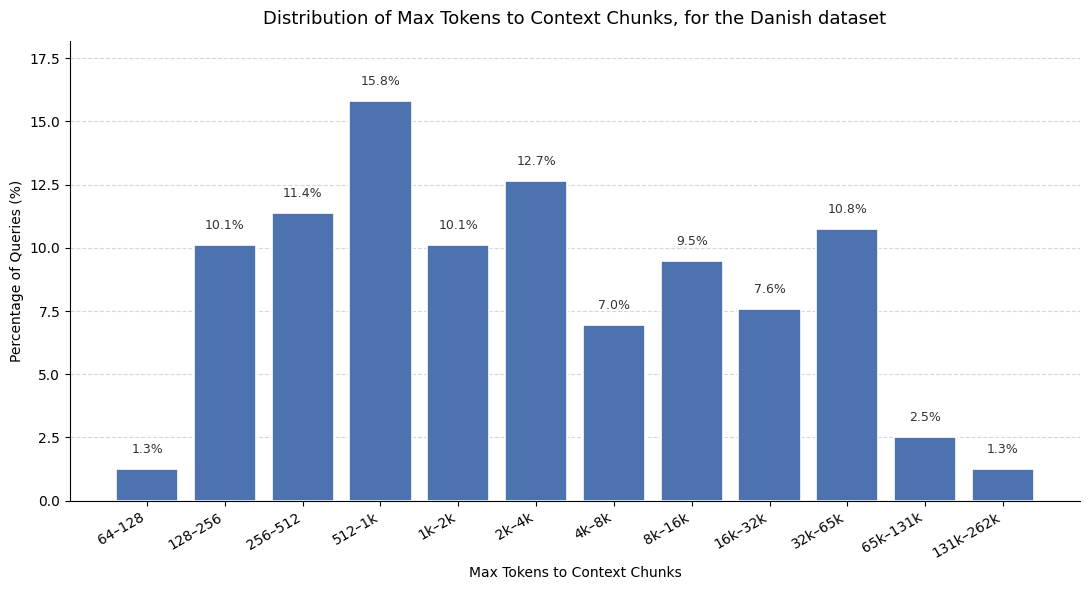

In [58]:
import numpy as np

bins = [2**i for i in range(6, 19)]  # 1, 2, 4, ..., 131072

def fmt_k(n):
    return f"{n//1000}k" if n >= 1000 else str(n)

bin_labels = [f"{fmt_k(lo)}–{fmt_k(hi)}" for lo, hi in zip(bins[:-1], bins[1:])]

counts, _ = np.histogram(queries['max_tokens_to_context_chunks'], bins=bins)
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(bin_labels))
bars = ax.bar(x, percentages, color='#4C72B0', edgecolor='white', linewidth=1.2)

for bar, pct in zip(bars, percentages):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=30, ha='right')
ax.set_xlabel('Max Tokens to Context Chunks')
ax.set_ylabel('Percentage of Queries (%)')
ax.set_title('Distribution of Max Tokens to Context Chunks, for the Danish dataset', fontsize=13, pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()

## DONE

In [95]:
# count how many queries per dataset
queries['dataset'] = queries['chunk_id'].apply(lambda x: x.split('_')[0])
dataset_counts = queries['dataset'].value_counts()
print(dataset_counts)

# pick a random sample of 5 from each dataset; if fewer than 5, take all. Print chunk_id
sampled_queries = queries.groupby('dataset').apply(lambda x: x.sample(n=min(4, len(x)), random_state=42)).reset_index(drop=True)
sampled_queries[['chunk_id', 'utilized_context_chunk_ids']]

dataset
selskabsloven        36
almenboligloven      29
serviceloven         29
aaregnskabsloven     27
barnetslov           19
straffeloven         14
erhversfondsloven     4
Name: count, dtype: int64


,chunk_id,utilized_context_chunk_ids
0,aaregnskabsloven_§138a_stk3,"[aaregnskabsloven_§138a_stk1, aaregnskabsloven..."
1,aaregnskabsloven_§137n_stk2,"[aaregnskabsloven_§137k_stk1, aaregnskabsloven..."
2,aaregnskabsloven_§138a_stk4,"[aaregnskabsloven_§138a_stk1, aaregnskabsloven..."
3,aaregnskabsloven_§151_stk5,[aaregnskabsloven_§151_stk3]
4,almenboligloven_§58b_stk1,[almenboligloven_§55_stk1]
5,almenboligloven_§98d_stk4,"[almenboligloven_§98d_stk1, almenboligloven_§9..."
6,almenboligloven_§169_stk2,"[almenboligloven_§164_stk2, almenboligloven_§1..."
7,almenboligloven_§179a_stk4,"[almenboligloven_§179a_stk1, almenboligloven_§..."
8,barnetslov_§49_stk3,[barnetslov_§49_stk1]
9,barnetslov_§201_stk1,[barnetslov_§163_stk1]


In [92]:
# take 5 from each dataset, with the least words in 'context_chunks'; if fewer than 5, take all. Print chunk_id only.
queries['num_context_chunks'] = queries['utilized_context_chunk_ids'].apply(len)
least_context_chunks = queries.groupby('dataset').apply(lambda x: x.nsmallest(n=min(4, len(x)), columns='num_context_chunks')).reset_index(drop=True)
print(least_context_chunks[['chunk_id', 'utilized_context_chunk_ids', 'num_context_chunks']])

                       chunk_id  \
0    aaregnskabsloven_§97a_stk4   
1   aaregnskabsloven_§137c_stk3   
2    aaregnskabsloven_§99b_stk5   
3      aaregnskabsloven_§7_stk1   
4    almenboligloven_§160e_stk2   
5    almenboligloven_§129a_stk1   
6     almenboligloven_§96b_stk3   
7    almenboligloven_§142c_stk2   
8           barnetslov_§49_stk3   
9          barnetslov_§178_stk5   
10         barnetslov_§188_stk2   
11         barnetslov_§201_stk1   
12  erhversfondsloven_§119_stk3   
13  erhversfondsloven_§101_stk1   
14   erhversfondsloven_§99_stk3   
15  erhversfondsloven_§109_stk3   
16      selskabsloven_§214_stk3   
17      selskabsloven_§290_stk3   
18       selskabsloven_§97_stk2   
19      selskabsloven_§273_stk2   
20       serviceloven_§130_stk1   
21       serviceloven_§163_stk1   
22        serviceloven_§12_stk2   
23      serviceloven_§131a_stk2   
24      straffeloven_§236_stk10   
25        straffeloven_§55_stk2   
26      straffeloven_§132b_stk5   
27       straffelove